# Biomedical Data Science 2026: Homework Assignment 1
### CBB & CPSC & S&DS (programming) Assignment

- Release Date: Week of Jan 26, 2026
- Due:  Feb 22nd, 11:59pm

#### Name:  Lynn Karam

# Instructions

* **You only need to write code between the `### START CODE HERE ###` and `### END CODE HERE ###` comments.**
* You may write code outside of these blocks, but it will not be graded.
* If you make use of any online resource please cite the source in the code comments.
* You may use some small utility functions directly, but notice that directly copying large chunks of codes (even with variable name replacement) are not allowed and will be considered as plagrism.
* After you are finished, **turn in the .ipynb file to canvas** (File->Download->Download .ipynb, then upload .ipynb files to assignment 1 in canvas).

# Part 1: Analyzing Protein Interaction Networks (35 pts)

## 1.1 - Data
- In this homework we use a real **COVID-19 dataset**: `COVID_human_UP.txt`, which contains genes that are up-regulated in SARS-CoV-2–positive nasopharyngeal swabs compared to controls.  
  - These genes are called **DEGs** (differentially expressed genes) because their expression levels differ significantly between COVID and non-COVID conditions.  
- As we discussed in lecture, proteins interact in networks, so mapping DEGs onto a **protein–protein interaction (PPI) network** helps us see how these dysregulated genes participate in pathways and complexes at the protein level.  
- In the following sections, we will load this DEG list and explore it in the context of a PPI network.  


In [ ]:
from google.colab import drive
drive.mount('/content/googledrive')

Mounted at /content/googledrive


In [ ]:
# Change directory to where your DEG files are stored. Update this path.
%cd "/content/googledrive/MyDrive/cbb7520_hw1"

# Replace 'your_deg_file.txt' with the actual filename and adjust parsing as needed.
with open('COVID_human_UP.txt', 'r') as f:
    degs = [line.strip() for line in f]

print(f"Loaded {len(degs)} DEGs.")

/content/googledrive/MyDrive/cbb7520_hw1
Loaded 1806 DEGs.


In [ ]:
degs[:5]

['A1BG', 'A2M', 'ABAT', 'ABCA1', 'ABO']

## 1.2 - Map to STRING Database

- STRING is a large database of known and predicted **protein–protein interactions**, integrating evidence from experiments, text mining, and other sources.  
  - In a PPI network, an **edge** means there is evidence that two proteins are functionally associated (sometimes a direct physical interaction, sometimes an indirect functional link). We use PPIs here to move from a “gene list” to a “mechanism-like” view—highlighting which DEGs may act together in pathways/complexes rather than in isolation.
- Here we used our COVID DEG list as input to the STRING API, retrieved interaction edges for these proteins, and filtered to high-confidence interactions.  
- From these edges we built a DEG-centered PPI subnetwork in NetworkX, so each differentially expressed gene is now mapped to its corresponding protein node and connected to its interaction partners in STRING.  
  - **NetworkX** is a Python library for creating and analyzing graphs/networks (nodes + edges). You’ll use it to store the PPI network and compute basic network properties. [Official docs & tutorial](https://networkx.org/documentation/stable/tutorial.html).


In [ ]:
# ==============================================================================
# Build PPI Network from STRING Database
# ==============================================================================

!pip install -q networkx pandas matplotlib requests markov_clustering scipy

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Fetch PPI data from STRING
def load_string_network(genes, species="9606"):
    """Retrieve protein interactions from STRING database."""
    url = "https://string-db.org/api/tsv/network"
    payload = {
        "identifiers": "\n".join(genes),
        "species": species,
        "limit": 1
    }
    resp = requests.post(url, data=payload)
    if resp.status_code != 200:
        raise RuntimeError(f"STRING API error: {resp.status_code}")
    return resp.text

In [ ]:
# Fetch STRING interactions for the DEG list
network_data = load_string_network(degs)

# Parse STRING output and filter to high-confidence edges
data = pd.read_csv(StringIO(network_data), sep="\t")
data_filtered = data[data["score"] > 0.7]

# Build a weighted PPI graph (nodes=genes, edges=STRING interactions)
G = nx.Graph()
for _, row in data_filtered.iterrows():
    G.add_edge(row["preferredName_A"], row["preferredName_B"], weight=row["score"])

for gene in degs:
    if gene not in G: # we include DEGs with no interactions as isolated nodes
        G.add_node(gene)

deg_subG = G.subgraph(set(degs)).copy()

print(f"\nDEG subnetwork: {deg_subG.number_of_nodes()} nodes, {deg_subG.number_of_edges()} edges")
print(f"Network density: {nx.density(deg_subG):.4f}")
print(f"Connected components: {nx.number_connected_components(deg_subG)}")


DEG subnetwork: 1806 nodes, 3646 edges
Network density: 0.0022
Connected components: 884


## 1.3 - Hub genes (5 pts)
- In a PPI network, **degree** is the number of interaction partners a protein has; proteins with very high degree are often called **hub genes/proteins**.  
- Such high-degree proteins often act as key regulators or scaffolds, helping coordinate many different cellular processes at once.  
- In this section, we will rank COVID DEGs by degree in the PPI subnetwork and ask whether these hubs highlight biological processes that are more active in COVID samples than in controls.
  - For now, just identify and list the top hub genes; you don’t need to writer biological interpretations until the next question/section.
- You can refer to the [official docs & tutorial for Networkx](https://networkx.org/documentation/stable/tutorial.html) for relevant functions.


In [ ]:
# ==============================================================================
# Identify Hub Genes
# ==============================================================================

## Instructions:
# In the DEG subnetwork deg_subG, use NetworkX to get degrees for all nodes
# and print the top 15 hub genes with highest degree (gene name and degree).

### START CODE HERE ###

degrees = deg_subG.degree()
top_15_hub_genes = sorted(degrees, key=lambda x: x[1], reverse=True)[:15]
print("Top 15 Hub Genes:")
for gene, degree in top_15_hub_genes:
    print(f"{gene}: {degree}")

### END CODE HERE ###

Top 15 Hub Genes:
CD8A: 97
IL1B: 80
PTPRC: 68
FCGR3A: 60
ITGAM: 60
TLR4: 59
CXCL10: 56
DDX58: 56
CD86: 55
CCL2: 51
ITGAX: 50
CCR5: 50
IFIH1: 50
ISG15: 47
CCL5: 47


## 1.4 - Interpret PPI results


### 1.4a: module detection

- To better interpret the PPI network for our DE genes, we next look for modules: groups of proteins that are more connected to each other than to the rest of the network. Biologically, these modules often correspond to protein complexes, pathways, or coordinated functional programs; they are often easier to interpret than isolated genes.

- We use **Markov Clustering (MCL)**, a widely used method for PPI module detection. MCL simulates flow / random-walk movement on the graph and separates regions where the flow tends to stay trapped, producing densely connected clusters;
  - One key hyperparameter of this method is the inflation parameter controls how coarse vs. fine the modules are (higher inflation usually produces more/smaller clusters; lower inflation produces fewer/larger clusters)..
  - you can refer to [this paper](https://www.nature.com/articles/s41556-023-01281-y) for an example of how MCL is used in a real STRING-based PPI workflow


Module sizes: [146, 53, 34, 18, 17]


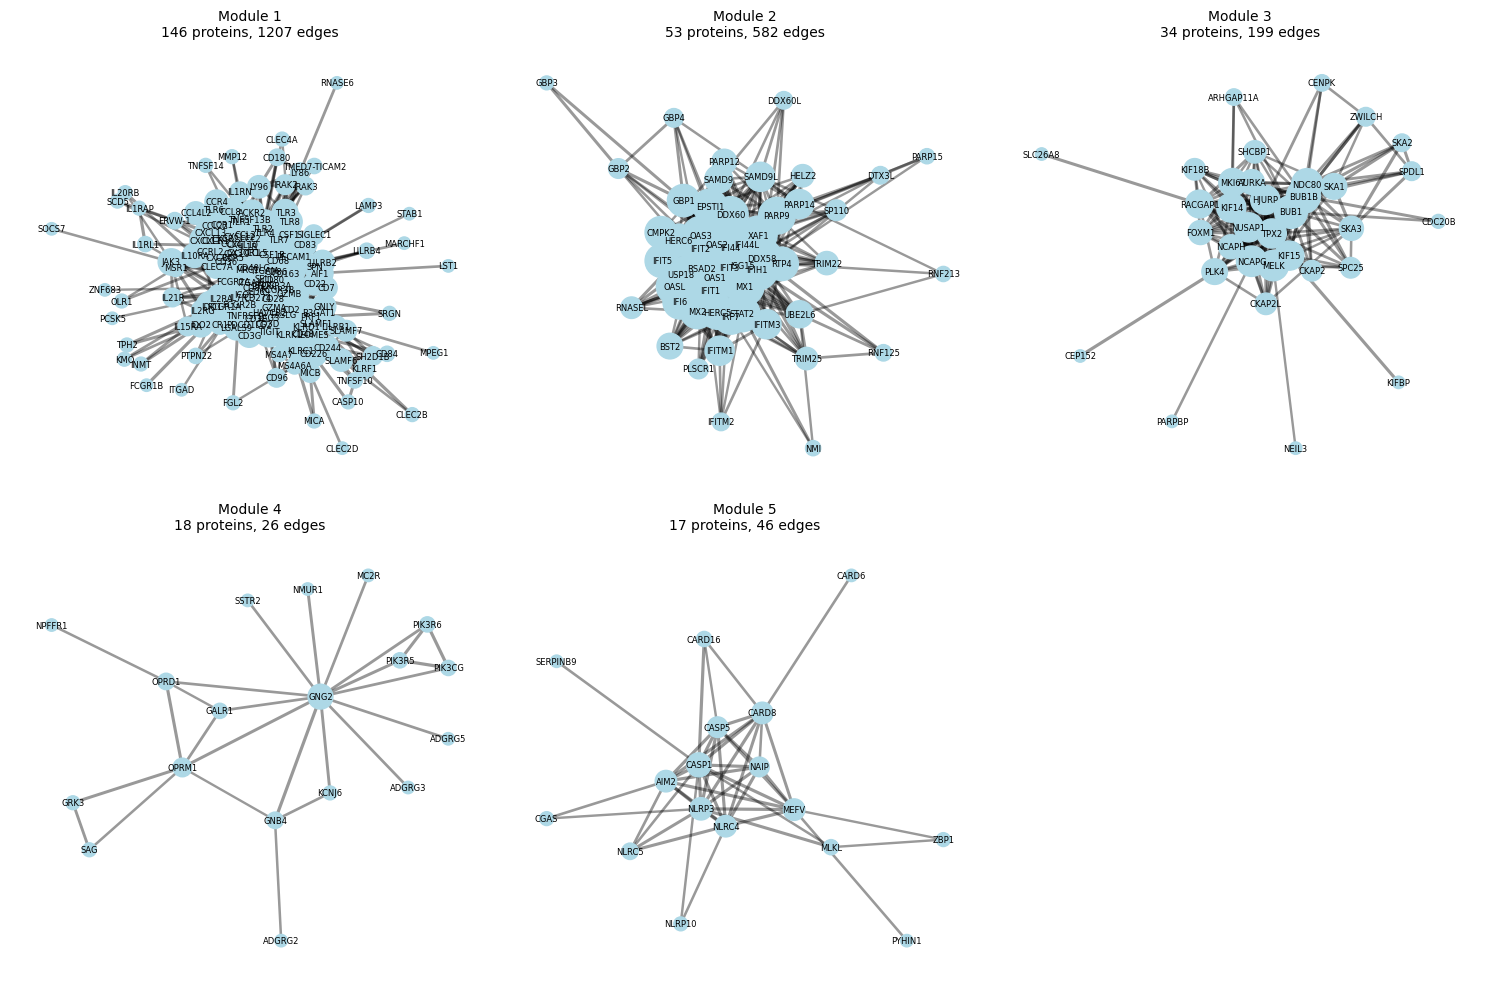

In [ ]:
# ==============================================================================
# Module Detection and Functional Analysis
# ==============================================================================

# --- 3.4.1: Markov Clustering ---

import markov_clustering as mc
import scipy.sparse as sp
import math

# Run MCL on the DEG network to identify modules
def detect_modules(graph, inflation=1.8):
    """Apply Markov clustering to identify network modules."""
    if graph.number_of_nodes() == 0:
        return []

    node_list = list(graph.nodes())
    adj_matrix = nx.to_scipy_sparse_array(graph, nodelist=node_list,
                                          weight="weight", dtype=float)
    adj_matrix = sp.csr_matrix(adj_matrix)

    # perform mcl clustering using package, w inflation as an adjustable hyperparameters
    result = mc.run_mcl(adj_matrix, inflation=inflation)
    clusters_idx = mc.get_clusters(result)

    modules = [[node_list[i] for i in cluster] for cluster in clusters_idx]
    return sorted(modules, key=len, reverse=True)

# Detect modules and keep the top 5 by size
modules = detect_modules(deg_subG, inflation=1.8)
modules = [m for m in modules if len(m) >= 10][:5]

print(f"Module sizes: {[len(m) for m in modules]}")

# Plot the top detected modules
def plot_module(graph, nodes, ax, title):
    """Visualize a single network module."""
    subgraph = graph.subgraph(nodes).copy()
    k = 1.0 / max(1, math.sqrt(len(nodes)))
    layout = nx.spring_layout(subgraph, seed=42, k=k)

    degrees = dict(subgraph.degree())
    sizes = [60 + 20 * degrees[n] for n in subgraph.nodes()]

    edge_weights = [d.get("weight", 1.0) for _, _, d in subgraph.edges(data=True)]
    widths = [0.3 + 2.0 * w for w in edge_weights]

    nx.draw_networkx_edges(subgraph, layout, width=widths, alpha=0.4, ax=ax)
    nx.draw_networkx_nodes(subgraph, layout, node_size=sizes,
                          node_color='lightblue', ax=ax)
    nx.draw_networkx_labels(subgraph, layout, font_size=6, ax=ax)

    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Plot modules
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, module in enumerate(modules):
    subG = deg_subG.subgraph(module)
    title = f"Module {idx+1}\n{subG.number_of_nodes()} proteins, {subG.number_of_edges()} edges"
    plot_module(deg_subG, module, axes[idx], title)

for ax in axes[len(modules):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### 1.4b: Module interpretation (30 pts)

- After detecting modules, we next interpret each top cluster by combining network structure with functional enrichment.  
- For each of the top 5 MCL modules, report both **hub genes** and **enriched functions**:
  - Top 10 hub genes = nodes with highest degree within the module subgraph.
  - Top 5 enriched GO BP terms + Top 5 enriched KEGG pathways = enrichment run on the full module gene list
    - GO terms: Gene Ontology “biological process” labels that summarize what kinds of processes the genes participate in (e.g., interferon signaling, apoptosis).

    - KEGG pathways: curated signaling and metabolic pathways that group genes into higher-level functional circuits (e.g., cytokine–cytokine receptor interaction).
- These hubs and enriched terms help us summarize what each module is functioning biologically.  
- **You will use these results to interpret the biological functions of each module and discuss which biological programs appear most perturbed in COVID vs. controls.**  


In [ ]:
# --- 3.4.2: Module-Level Hub Genes and Enrichment ---

# you might consider using the following package for gene set enrichment analysis
!pip install -q gseapy
import gseapy as gp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 9.8 MB/s eta 0:00:00


- You can find a worked example for gseapy Enrichr API [here](https://gseapy.readthedocs.io/en/latest/gseapy_example.html#Enrichr-API)

In [ ]:
gp.get_library_name()  # first check all available databases

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

Following the instructions below, we can use either 'GO_Biological_Process_2021', 'GO_Biological_Process_2023', or 'GO_Biological_Process_2025' to obtain the enriched GO terms. For the KEGG pathways we can use 'KEGG_2019_Human' or 'KEGG_2021_Human'.

In [ ]:
for idx, module in enumerate(modules):
    print(f"\nMODULE {idx+1} ({len(module)} genes)")
    print("-"*30)

    ## Instructions
    # 1. Compute node degrees within the module subgraph and print the top 10 hub genes (gene name and degree).
    # 2. To obtain enriched GO terms and KEGG pathways, you can use gseapy.enrichr as a quick-start,
    #    (this is a Python wrapper around the Enrichr web tool for quick over-representation enrichment);
    #    this runs a Fisher over-representation test relative to Enrichr’s built-in background for each library.
    #    Feel free to use other enrichment tools/pipelines as well.
    # 3. From the enrichment results, print the top 5 GO terms and top 5 KEGG pathways (term and its adjusted p-values).


    ### START CODE HERE ###

    # Part 1.
    module_subgraph = deg_subG.subgraph(module)   # get the subgraph
    module_degrees = module_subgraph.degree()     # compute the degrees
    top_10_hub_genes = sorted(module_degrees, key=lambda x: x[1], reverse=True)[:10]    # sort the top 10 hub genes

    print(f"\nTop 10 hub genes in module {idx+1}:")
    for gene, degree in top_10_hub_genes:
        print(f"  {gene}: {degree}")    # print gene name and degree

    # Part 2.
    go_results = gp.enrichr(gene_list=module, gene_sets='GO_Biological_Process_2025', organism='human') # use Enrichr
    kegg_results = gp.enrichr(gene_list=module, gene_sets='KEGG_2021_Human', organism='human')

    # Part 3.
    print(f"\nTop 5 enriched GO biological process terms:")
    results_df = go_results.results.sort_values('Adjusted P-value')
    for i in range(5): # loop 5 times for the top 5 GO terms and KEGG pathways
        if i < len(results_df):
            print(f"  {results_df.iloc[i]['Term']}: p-adj = {results_df.iloc[i]['Adjusted P-value']:.2e}")

    print(f"\nTop 5 enriched KEGG pathways:")
    kegg_df = kegg_results.results.sort_values('Adjusted P-value')
    for i in range(5):
        if i < len(kegg_df):
            print(f"  {kegg_df.iloc[i]['Term']}: p-adj = {kegg_df.iloc[i]['Adjusted P-value']:.2e}")

    ### END CODE HERE ###


MODULE 1 (146 genes)
------------------------------

Top 10 hub genes in module 1:
  CD8A: 87
  IL1B: 56
  PTPRC: 53
  CD86: 53
  FCGR3A: 52
  ITGAM: 48
  CCR5: 45
  TLR4: 42
  FCGR3B: 42
  CD80: 42

Top 5 enriched GO biological process terms:
  Inflammatory Response (GO:0006954): p-adj = 4.03e-27
  Cytokine-Mediated Signaling Pathway (GO:0019221): p-adj = 1.20e-23
  Regulation of Tumor Necrosis Factor Production (GO:0032680): p-adj = 1.99e-21
  Cellular Response to Lipopolysaccharide (GO:0071222): p-adj = 1.68e-20
  Cellular Response to Molecule of Bacterial Origin (GO:0071219): p-adj = 3.01e-19

Top 5 enriched KEGG pathways:
  Cytokine-cytokine receptor interaction: p-adj = 1.07e-34
  Viral protein interaction with cytokine and cytokine receptor: p-adj = 6.70e-32
  Toll-like receptor signaling pathway: p-adj = 1.70e-18
  Chemokine signaling pathway: p-adj = 3.20e-16
  Hematopoietic cell lineage: p-adj = 4.20e-16

MODULE 2 (53 genes)
------------------------------

Top 10 hub genes i

**Type your observations here (double click to edit): based on the hub genes and enriched GO/KEGG terms, summarize the main functions of each module and what they suggest about COVID vs. controls.**

The 5 modules show different biological processes affected by COVID. These show that infection is associated with a general immune system activation, an antiviral defense mechanism, changes in cell proliferation, some neurological signaling, cytokine signaling, and inflammatory activations compared to controls. Below are further explanations.

Module 1 is enriched for inflammatory and cytokine signaling pathways and contains hub genes such as CD8A, IL1B, PTPRC and TLR4. These genes are involved in immune cell activation, pathogen recognition (response to lipopolysaccharide), cytokine-cytokine receptor interaction, viral protein interaction with cytokine, and Toll-like receptor signaling. These enrichments suggest heightened immune activation and inflammation in COVID samples in response to infection vs controls.

Module 2 is dominated by interferon (IFN) signaling pathways, consisting of what are known as interferon-stimulated genes, and antiviral response genes. Examples include IFIT3, IFIH1, IFI44L, and IFIT2. Enrichment for defense response to virus and viral infection pathways indicates activation of innate antiviral immunity. This suggests that COVID infection induces a strong interferon-mediated antiviral response.

Module 3 contains hub genes involved in cell cycle regulation processes and mitosis, including BUB1, BUB1B, and NDC80. Enrichment for chromatid segregation and mitotic division suggests increased cell proliferation and cell cycle activity, possibly reflecting immune cell expansion or tissue repair processes during infection.

Module 4 is enriched for GPCR and neuroactive signaling pathways and includes genes such as GNG2, OPRM1, and GNB4. These pathways are involved in signal transduction and neurotransmitter responses. This suggests potential effects of COVID on neural signaling, immune cell communication, or stress-related pathways.

Module 5 is dominated by inflammatory responses and pathways consisting of intracellular receptors that detect pathogens or cellular damage. It contains hub genes like CASP1, NLRP3, and AIM2. These genes trigger pyroptosis and interleukin-1 Beta production, which again suggests that this module drives inflammation responses in COVID patients.

In conclusion, the modules reflect both innate and adaptive immune responses, as well as inflammatory dysregulation during infection, and these patterns are consistent with responses observed in severe COVID cases.


# Part 2: Transcription Factor Binding in ChIP-seq Data (40 pts)

* In this part, you will follow a guided walkthrough of the classic “k-mer features + classifier” strategy from Discriminative Prediction of Mammalian Enhancers from DNA Sequence (Lee, Karchin, Beer). [paper link](https://genome.cshlp.org/content/21/12/2167.full).

* This gives you a preview of a standard ML workflow and a chance to explore the data and outputs. We will explain the underlying machine learning ideas more deeply in lecture later. For now, the goal is to build a working predictor and interpret what it learns in TF motif / biology terms.
* We will use a simulated ChIP-seq TF binding dataset consisting of 50-bp DNA sequences (kept short so it’s easy to experiment), paired with binary labels indicating whether the TF binds. Recall that ChIP-seq (as we covered in lecture) is an assay that uses antibody pull-down + sequencing to identify genomic regions bound by a protein. In this dataset, label 1 = binding (TF bound) and label 0 = non-binding (TF did not bind).
  * Sources of the simulated data: [paper link](https://www.nature.com/articles/s41588-018-0295-5)

  * (Spoiler alert: the true regulatory motif is *`CGACCGAACTCC`*. Of course, the model doesn't know this.)

Let's first load the data, which consists of DNA sequences and their corresponding labels.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

np.random.seed(0)

SEQUENCES_URL = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/sequences.txt'

sequences = requests.get(SEQUENCES_URL).text.split('\n')
sequences = list(filter(None, sequences))  # This removes empty sequences.

# Let's print the first few sequences.
pd.DataFrame(sequences, index=np.arange(1, len(sequences)+1),
             columns=['Sequences']).head()

,Sequences
1,CCGAGGGCTATGGTTTGGAAGTTAGAACCCTGGGGCTTCTCGCGGA...
2,GAGTTTATATGGCGCGAGCCTAGTGGTTTTTGTACTTGTTTGTCGC...
3,GATCAGTAGGGAAACAAACAGAGGGCCCAGCCACATCTAGCAGGTA...
4,GTCCACGACCGAACTCCCACCTTGACCGCAGAGGTACCACCAGAGC...
5,GGCGACCGAACTCCAACTAGAACCTGCATAACTGGCCTGGGAGATA...


Similarly, we can go ahead and load the labels. In this case, the labels are structured as follows: a "1" indicates that a protein bound to the sequence, while a "0" indicates that the protein did not.

In [ ]:
LABELS_URL = 'https://raw.githubusercontent.com/abidlabs/deep-learning-genomics-primer/master/labels.txt'

# Load labels from URL
labels = requests.get(LABELS_URL).text.split('\n')
labels = list(filter(None, labels))  # Remove empty entries

# Convert labels to NumPy array and ensure correct shape (B, 1)
labels = np.array(labels, dtype=np.float32).reshape(-1, 1)

print('Labels:\n', labels.T)

Labels:
 [[0. 0. 0. ... 0. 1. 1.]]


## 2.1 - Curate the Data
**Extracting k-mer Features for Classification**. Machine learning models typically require numeric inputs, so we can’t feed raw ACGT strings directly into most classifiers. A common solution in regulatory sequence prediction is to represent each sequence by the k-mers it contains. A k-mer is simply a length-k substring (e.g., for k=6, “ACGTTA” is one 6-mer). By turning each sequence into a vector of k-mer frequencies, we give the model a standardized “feature profile” it can compare across sequences.

For each sequence, we will count occurrences of all possible k-mers (subsequences of length k) and normalize these counts to obtain frequency-based feature representations. These feature vectors will then be used to train an ML model to separate positive (binding) and negative (non-binding) sequences. **You can refer to Figure 1A of the paper for a clear diagram.**


In [ ]:
import numpy as np
from collections import Counter
from itertools import product

def kmer_transform(sequences, labels, k):
    """Convert DNA sequences into k-mer frequency tables for ML models."""
    kmers = [''.join(p) for p in product("ACGT", repeat=k)]
    X_transformed = []

    for seq in sequences:
        kmer_counts = Counter(seq[i:i+k] for i in range(len(seq) - k + 1))
        total_kmers = sum(kmer_counts.values())
        normalized_counts = [kmer_counts[kmer] / total_kmers if total_kmers > 0 else 0 for kmer in kmers]
        X_transformed.append(normalized_counts)

    return np.array(X_transformed), np.array(labels), kmers  # Return feature names

We start by splitting the dataset into training (80%) and test (20%) sets, ensuring the test set remains independent for final evaluation. We do this so the model can learn patterns from the training set, while the test set stays as unseen data for an honest check of how well the model generalizes. In other words, the test set helps us avoid accidentally “grading ourselves” on examples the model has already seen.

In [ ]:
from sklearn.model_selection import train_test_split

k = 4  # Adjust as needed

# Transform sequences
X, y, feature_names = kmer_transform(sequences, labels, k)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check data shapes
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1600, 256) Test shape: (400, 256)


## 2.2 - Train a classifier (20 pts)

In this step, you will train an Support Vector Machine (SVM) to predict transcription factor binding using the k-mer features extracted above. The paper focuses on SVM, but **feel free to explore any ML model of your choice in this section**.

To choose settings responsibly, we will use **cross-validation (CV)** and **hyperparameter tuning**. CV repeatedly splits the *training set* into smaller train/validation folds so you can estimate how well a model might perform on unseen sequences (without touching the true test set). Hyperparameter tuning (via grid search or randomized search) tries different model settings (e.g., SVM `C`, kernel choice) and uses CV to select the best-performing option.

**Grid search / randomized search:**  
If you're new to these ideas, use scikit-learn's worked example as a concrete template for what “GridSearchCV + CV + final evaluation split” looks like in practice:

- Worked example (GridSearchCV + CV + held-out evaluation): https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html  
- Cross-validation overview: https://scikit-learn.org/stable/modules/cross_validation.html
- SVM overview: https://scikit-learn.org/stable/modules/svm.html


**Instructions:**
* Define an ML model of your choise and perform hyperparameter search using `RandomizedSearchCV` or `GridSearchCV`, which applies 5-fold cross-validation (CV) within the training set to evaluate different hyperparameter combinations and select the best model.
* Select the best model based on CV performance, which is further used for final evaluation.
* Depending on the model you choose, here are some hyperparameter options you might want to consider:


```
# parameters search grid for model classes
rf_params = {'class_weight':['balanced'], 'n_estimators':[5, 10, 25, 50, 100],
              'min_impurity_decrease': [0, .1, .5], 'criterion': ['gini', 'entropy']}

svm_params = {'C':[0.25, 0.5, 1, 2], 'kernel':['linear', 'rbf', 'poly', 'sigmoid'],
              'degree':[2, 3, 4], 'class_weight':['balanced'],
              'probability': [True]}

xgb_params = {'n_estimators':[1, 2, 4, 8], 'booster':['gbtree', 'gblinear', 'dart'],
              'reg_alpha':[0.001, 0.01, 0.1, .5, 1], 'reg_lambda':[0.001, 0.01, 0.1, .5 ,1]}
```



In [ ]:
from sklearn.svm import SVC  # you can add your model here
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

### START CODE HERE ###

svm_model = SVC(random_state=42)    # define the model

# define hyperparameters to search (I use the ones that are given in the instructions)
svm_params = {'C':[0.25, 0.5, 1, 2], 'kernel':['linear', 'rbf', 'poly', 'sigmoid'],
              'degree':[2, 3, 4], 'class_weight':['balanced'],
              'probability': [True]}

# set up GridSearchCV with 5-fold cross-validation (from instructions)
search = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy') # use accuracy so that I know what % does my model correctly predict if TF binds or not

# train and find best model
search.fit(X_train, y_train)

# get the best model based on CV performance
best_model = search.best_estimator_

print(f"Best parameters: {search.best_params_}")
print(f"Best CV accuracy: {search.best_score_:.4f}")

### END CODE HERE ###

Best parameters: {'C': 0.25, 'class_weight': 'balanced', 'degree': 4, 'kernel': 'poly', 'probability': True}
Best CV accuracy: 0.9969


## 2.3 - Evaluate (5 pts)
After choosing the best model using only the training set (and CV inside it), you evaluate once on the held-out test set to estimate how well the model works on truly unseen sequences.

Test the model by making predictions on the test set and **printing the accuracy**.

In [ ]:
from sklearn.metrics import accuracy_score

### START CODE HERE ###

y_pred = best_model.predict(X_test)               # make predictions on test set
test_accuracy = accuracy_score(y_test, y_pred)    # get accuracy

print(f"Test set accuracy: {test_accuracy:.4f}")

### END CODE HERE ###

Test set accuracy: 0.9950


## 2.4 - Feature importance (15 pts)

Once a classifier works, we want to interpret which k-mers are most informative for predicting binding. This step is the bridge back to biology: the “important” k-mers should often look like pieces of the real motif or closely related variants.

Common approaches:

[Permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html): shuffle one feature (one k-mer column) and see how much performance drops—bigger drop suggests that k-mer matters.

[SHAP](https://shap.readthedocs.io/en/latest/): assigns feature-attribution scores to quantify how features contribute to predictions (more advanced; use if you’re comfortable).

**Instructions:**
* Implement feature importance analysis using methods such as permutation test, SHAP, or any other suitable approach.
* Identify and report the top 5 k-mer features that contribute most to the model’s predictions.
* Compare the top k-mers with the true regulatory motif (*`CGACCGAACTCC`*) and report your observations.

**Sources I used for this part of the homework**

Link 1: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html

Link 2: https://scikit-learn.org/stable/modules/permutation_importance.html

Link 3: https://www.w3schools.com/python/ref_func_zip.asp

In [ ]:
### START CODE HERE ###

from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy') # calculate permutation importance on test set
importance_scores = perm_importance.importances_mean                                 # get importance scores
kmer_importance = list(zip(feature_names, importance_scores))                        # create a list of (k-mer, importance) pairs
kmer_importance_sorted = sorted(kmer_importance, key=lambda x: x[1], reverse=True)   # sort by descending importance
top_5_kmers = kmer_importance_sorted[:5]                                             # get top 5

print("Top 5 most important k-mers:")
for i, (kmer, importance) in enumerate(top_5_kmers, 1):
    print(f"{i}. {kmer}: {importance:.4f}")

### END CODE HERE ###

Top 5 most important k-mers:
1. CCGA: 0.0137
2. ACCG: 0.0080
3. AACT: 0.0080
4. CTCC: 0.0057
5. ACTC: 0.0052


**type your observation here (double click to edit)**

From above, we were told that the true motif is CGACCGAACTCC.

The top 5 most important k-mers are:

* CCGA: 0.0137 which appears in CGA**CCGA**ACTCC
* ACCG: 0.0080 which appears in CG**ACCG**AACTCC
* AACT: 0.0080 which appears in CGACCG**AACT**CC
* CTCC: 0.0057 which appears in CGACCGAA**CTCC**
* ACTC: 0.0052 which appears in CGACCGA**ACTC**C

The top k-mers are overlapping substrings of the true motif, which indicates that the model assigns high importance to sequence regions within the transcription factor binding site. Because multiple overlapping k-mers from the same motif are identified, this suggests that the classifier successfully captured the underlying biological signal rather than false sequence patterns. This shows that permutation importance effectively highlights biologically meaningful features related to transcription factor binding.
